*original code by LEONARDO FERREIRA*

<h4>Exercise 5a, predicting credit risk

In this exercise, we predict credit risk based on a German credit data set.

1. We visualize the data and draw some bars and violin graphs, and a correlation matrix
2. We estimate the credit score (good, bad) using several classifiers
3. We estimate the credit score using random forest and grid search. 

Columns in the data: 

1. Age (numeric)
2. Sex (text: male, female)
3. Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)
4. Housing (text: own, rent, or free)
5. Saving accounts (text - little, moderate, quite rich, rich)
6. Checking account (numeric, in DM - Deutsch Mark)
7. Credit amount (numeric, in DM)
8. Duration (numeric, in month)
9. Purpose(text: car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others
10. Risk (Value target - Good or Bad Risk)

Q: how would you quantify the non-numeric variables for ML?

In [1]:
#pip install nbformat
#pip install plotly
#pip install Jinja2
#pip install xgboost
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

import warnings

#Importing the data
df_credit = pd.read_csv("german_credit_data.csv",index_col=0)

In [2]:
#Searching for Missings,type of data and also known the shape of data
print(df_credit.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB
None


In [3]:
#Looking unique values
print(df_credit.nunique())


Age                  53
Sex                   2
Job                   4
Housing               3
Saving accounts       4
Checking account      3
Credit amount       921
Duration             33
Purpose               8
Risk                  2
dtype: int64


Print the head of the data to see what it contains. 

In [4]:
#Looking the data
print(df_credit.head())

   Age     Sex  Job Housing Saving accounts Checking account  Credit amount  \
0   67    male    2     own             NaN           little           1169   
1   22  female    2     own          little         moderate           5951   
2   49    male    1     own          little              NaN           2096   
3   45    male    2    free          little           little           7882   
4   53    male    2    free          little           little           4870   

   Duration              Purpose  Risk  
0         6             radio/TV  good  
1        48             radio/TV   bad  
2        12            education  good  
3        42  furniture/equipment  good  
4        24                  car   bad  


In [5]:
x = df_credit[df_credit["Risk"]== 'good']["Risk"].value_counts().index.values

We compute and plot how many good and bad credit scorings there are. You can use matplotlib.

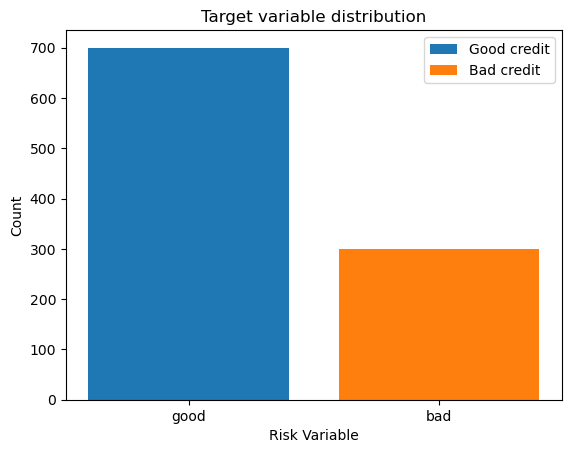

In [6]:
# Assuming df_credit is a pandas DataFrame with the 'Risk' column

good_credit_counts = df_credit[df_credit["Risk"] == 'good']["Risk"].value_counts()
bad_credit_counts = df_credit[df_credit["Risk"] == 'bad']["Risk"].value_counts()

fig, ax = plt.subplots()

# Creating bar charts for good and bad credit
ax.bar(good_credit_counts.index.values, good_credit_counts.values, label='Good credit')
ax.bar(bad_credit_counts.index.values, bad_credit_counts.values, label='Bad credit')

# Adding labels and title
ax.set_ylabel('Count')
ax.set_xlabel('Risk Variable')
ax.set_title('Target variable distribution')

# Adding legend
ax.legend()

# Display the plot
plt.show()

Next, we plot and age histograms of god and bad risk. Draw a similars histogram of good and bad credit as a function of the duration of the debt. ('Duration')

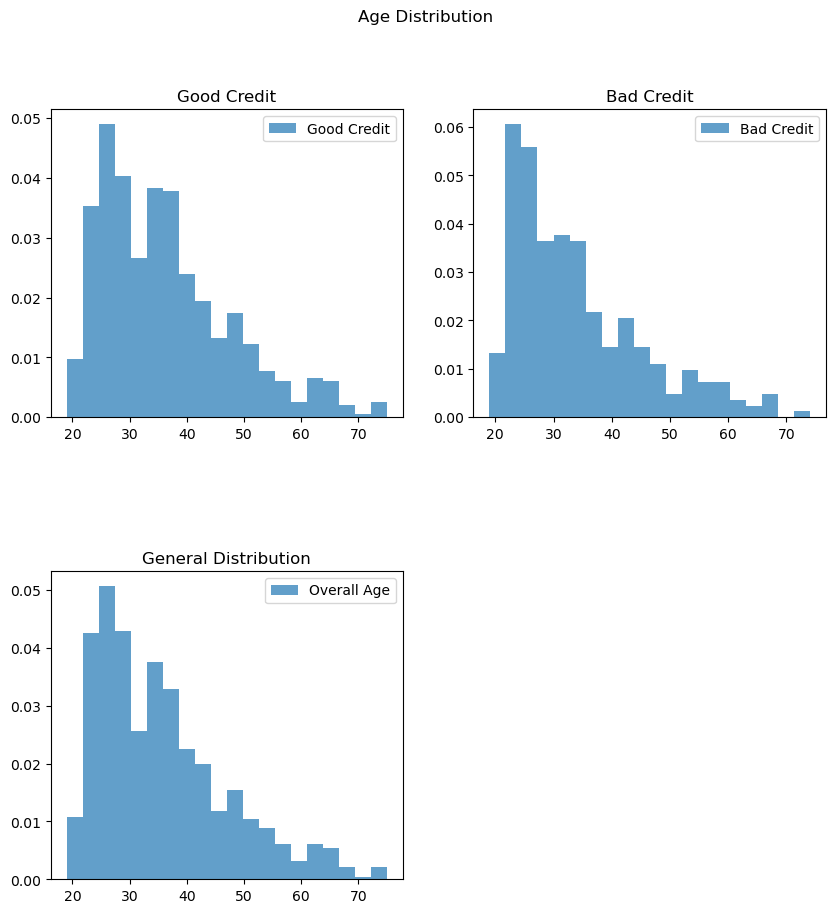

In [7]:
# Assuming df_credit DataFrame is already defined and contains the 'Risk' and 'Age' columns
df_good = df_credit[df_credit["Risk"] == 'good']['Age'].tolist()
df_bad = df_credit[df_credit["Risk"] == 'bad']['Age'].tolist()
df_age = df_credit['Age'].tolist()

# Creating the histogram plots
fig, axs = plt.subplots(2, 2, figsize=(10, 10))

# Adjusting the space between plots
plt.subplots_adjust(hspace=0.5)

# Good Credit Histogram
axs[0, 0].hist(df_good, bins=20, density=True, alpha=0.7, label='Good Credit')
axs[0, 0].set_title('Good Credit')
axs[0, 0].legend()

# Bad Credit Histogram
axs[0, 1].hist(df_bad, bins=20, density=True, alpha=0.7, label='Bad Credit')
axs[0, 1].set_title('Bad Credit')
axs[0, 1].legend()

# Overall Age Histogram
axs[1, 0].hist(df_age, bins=20, density=True, alpha=0.7, label='Overall Age')
axs[1, 0].set_title('General Distribution')
axs[1, 0].legend()

# Hide the empty subplot (bottom right)
axs[1, 1].axis('off')

# Setting the main title
plt.suptitle('Age Distribution')

# Display the plot
plt.show()

We set age intervals and name them as student, young, adult, and senior. We then present the amounts of credit of each cathegory as boxes. 
We also split the dataframes to df_good and df_bad.

In [8]:
#Let's look the Credit Amount column
interval = (18, 25, 35, 60, 120)

cats = ['Student', 'Young', 'Adult', 'Senior']
df_credit["Age_cat"] = pd.cut(df_credit.Age, interval, labels=cats)


df_good = df_credit[df_credit["Risk"] == 'good']
df_bad = df_credit[df_credit["Risk"] == 'bad']

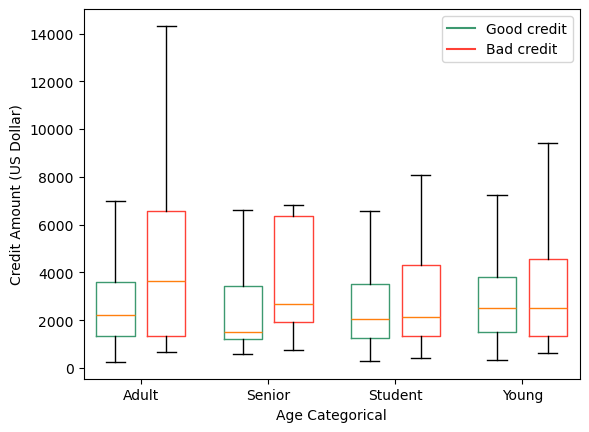

In [9]:
# Assuming df_good and df_bad are pandas DataFrames with 'Credit amount' and 'Age_cat' columns.
good_credit = df_good[['Credit amount', 'Age_cat']].copy()
bad_credit = df_bad[['Credit amount', 'Age_cat']].copy()

# Create a list of unique age categories
age_categories = sorted(set(good_credit['Age_cat'].unique()).union(set(bad_credit['Age_cat'].unique())))

# Prepare data for plotting
data_good = [good_credit[good_credit['Age_cat'] == age]['Credit amount'].values for age in age_categories]
data_bad = [bad_credit[bad_credit['Age_cat'] == age]['Credit amount'].values for age in age_categories]

# Plot
fig, ax = plt.subplots()
bpl = ax.boxplot(data_good, positions=np.array(range(len(data_good)))*2.0-0.4, sym='', widths=0.6)
bpr = ax.boxplot(data_bad, positions=np.array(range(len(data_bad)))*2.0+0.4, sym='', widths=0.6)

# Styling - colors
plt.setp(bpl['boxes'], color='#3D9970')
plt.setp(bpr['boxes'], color='#FF4136')

# Adding legend
plt.plot([], c='#3D9970', label='Good credit')
plt.plot([], c='#FF4136', label='Bad credit')
plt.legend()

# Set the axes labels
ax.set_xticks(range(0, len(age_categories) * 2, 2))
ax.set_xticklabels(age_categories)
ax.set_xlabel('Age Categorical')
ax.set_ylabel('Credit Amount (US Dollar)')

# Show the plot
plt.show()

As above, draw bars where the good and bad credits are plotted as functions of housing (own, rent, free). 
We can use to piece of code for Bars given above, making small changes such as the following:     
x = df_credit[df_credit["Risk"]== 'good']["Housing"].value_counts().index.values,

Then, change housing to 'Age'. You can see how informative the graph is. 

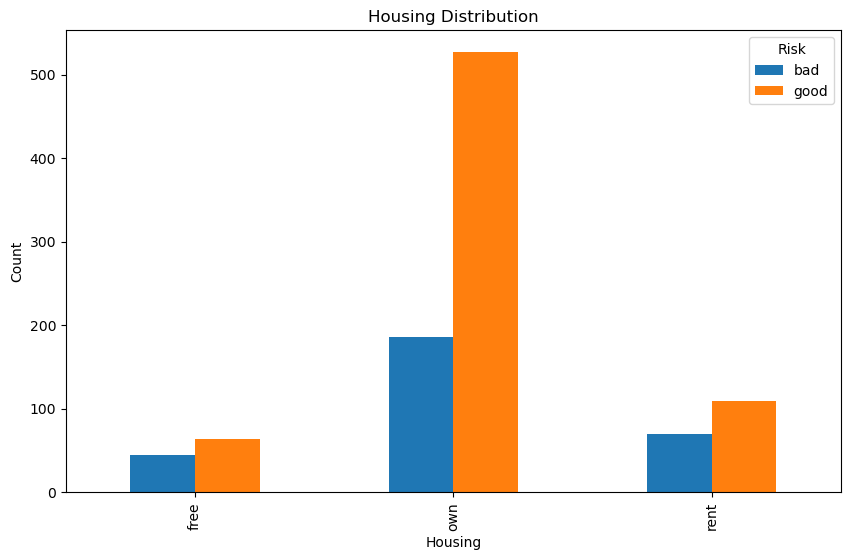

In [10]:
# Convert the 'Housing' column into a categorical type for better handling by seaborn
x = df_credit['Housing'].astype('category')

# Create a new DataFrame that contains the counts for each combination of 'Housing' and 'Risk'
housing_counts = df_credit.groupby(['Housing', 'Risk']).size().unstack(fill_value=0)

# Plotting using seaborn
fig, ax = plt.subplots(figsize=(10, 6))
housing_counts.plot(kind='bar', ax=ax)
# Title and labels
ax.set_title('Housing Distribution')
ax.set_xlabel('Housing')
ax.set_ylabel('Count')

# Show the plot
plt.show()


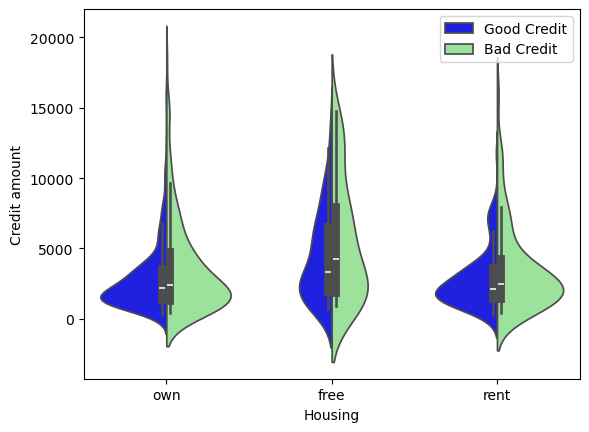

In [11]:
# Assuming df_good and df_bad are pandas DataFrames with the appropriate data.
# First, we would need to concatenate the good and bad DataFrames and create a new column to label the data accordingly.
df_good = df_good.copy()  # Create a copy of the DataFrame to avoid the SettingWithCopyWarning
df_good['Credit_Type'] = 'Good Credit'

df_bad = df_bad.copy()  # Create a copy of the DataFrame to avoid the SettingWithCopyWarning
df_bad['Credit_Type'] = 'Bad Credit'

df = pd.concat([df_good, df_bad])

# Now we can create the violin plot using Seaborn.
sns.violinplot(x='Housing', y='Credit amount', hue='Credit_Type', data=df,
                split=True, inner='box', palette={'Good Credit': 'blue', 'Bad Credit': 'lightgreen'})

# Adding the legend
plt.legend()

# Display the plot
plt.show()

Q: What would you say about the relationship between housing style and good and bad credit?

Next, as above, plot bars and boxes, were good credit and bad credit are plotted as functions of the sex. (4 bars: male good credit, male bad credit, female good credit, female bad credit) 

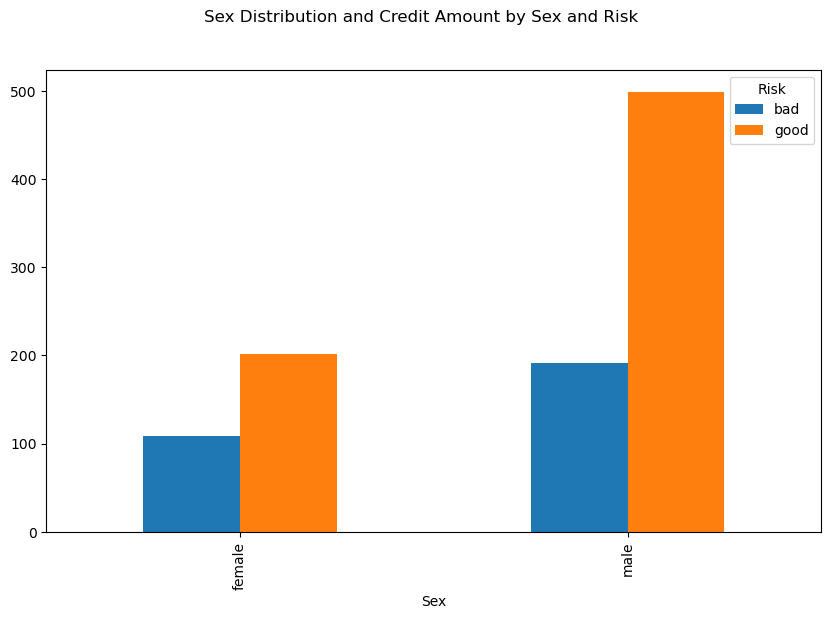

In [12]:

# Create a figure with 1 row and 2 columns for subplots
x = df_credit['Sex'].astype('category')
# First subplot - bar plots for Sex count by credit risk
sex_counts = df_credit.groupby(['Sex', 'Risk']).size().unstack(fill_value=0)

# Second subplot - box plots for Credit amount by Sex and credit risk
fig, ax = plt.subplots(figsize=(10, 6))
sex_counts.plot(kind='bar', ax=ax)

# Set an overall title
plt.suptitle('Sex Distribution and Credit Amount by Sex and Risk')

# Show the plots
plt.show()

We are interested in how the job is related to good or bad credit. Plot similar bars as above with good or bad credit risk and "Job". 

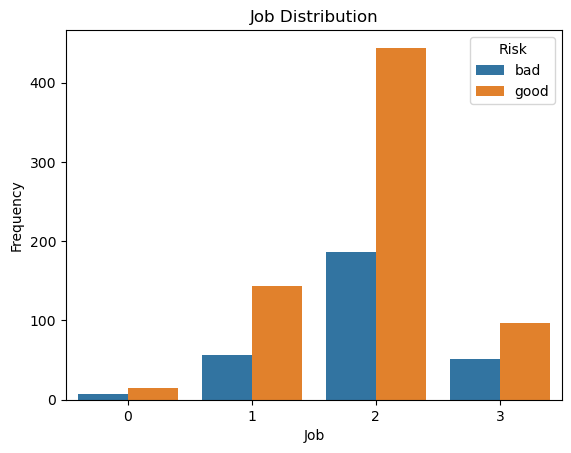

In [23]:
# Data preparation
df_credit_grouped = df_credit.groupby(['Job', 'Risk']).size().reset_index(name='Frequency')
df_credit_grouped['Risk'] = df_credit_grouped['Risk']

# Plotting
sns.barplot(x='Job', y='Frequency', hue='Risk', data=df_credit_grouped)

# Customization
plt.title('Job Distribution')

# Display plot
plt.show()

To close this section, draw boxes where x refers to 'Job' conditional on good credit/bad creidt and y to 'Credit amount' conditional on good or bad credit. Hint: Use the dataframes  df_good and df_bad defined earlier. 

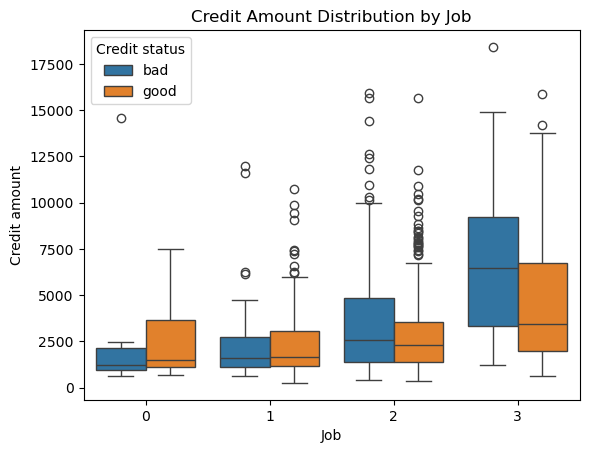

In [26]:
# Rename the 'good' and 'bad' categories to 'Good credit' and 'Bad credit'
df['Credit status'] = df['Risk'].astype('category')

# Now when you plot, these new labels will be used
sns.boxplot(x='Job', y='Credit amount', hue='Credit status', data=df)
plt.title('Credit Amount Distribution by Job')
plt.show()

Q: Then take a look at the violin patterns below. There are clear differences. Which is the most obvious result?

Job (numeric: 0 - unskilled and non-resident, 1 - unskilled and resident, 2 - skilled, 3 - highly skilled)

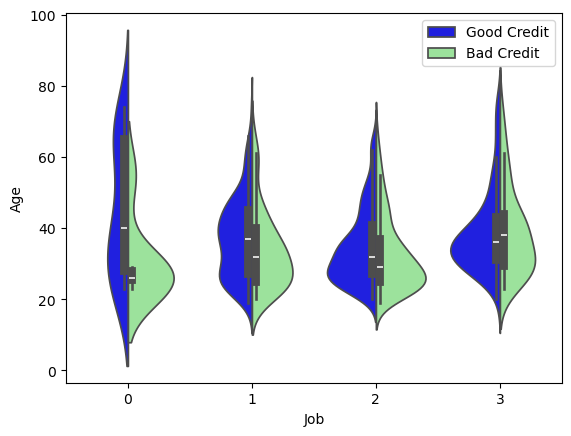

In [27]:
# First, we would need to concatenate the good and bad DataFrames and create a new column to label the data accordingly.
df_good.loc[:,'Credit_Type'] = 'Good Credit'
df_bad.loc[:,'Credit_Type'] = 'Bad Credit'
df = pd.concat([df_good, df_bad])

# Now we can create the violin plot using Seaborn.
sns.violinplot(x='Job', y='Age', hue='Credit_Type', data=df,
                split=True, inner='box', palette={'Good Credit': 'blue', 'Bad Credit': 'lightgreen'})

# Adding the legend
plt.legend()

# Display the plot
plt.show()

We are interested in the purpose of using credit. Is there a difference between female and male? You can use `pd.crosstab()` 

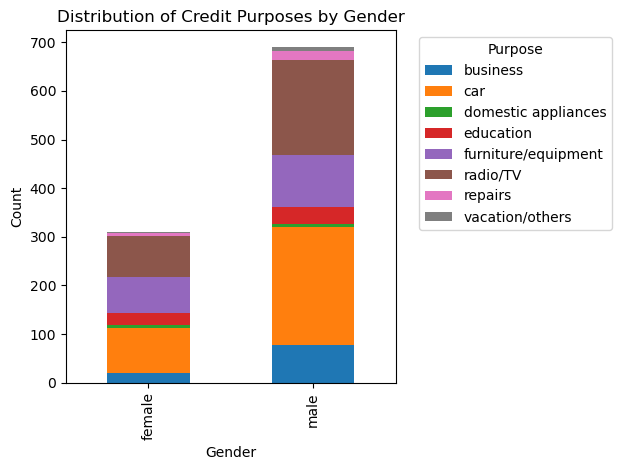

In [30]:
# Create a crosstab between Sex and Purpose
crosstab = pd.crosstab(df_credit['Sex'], df_credit['Purpose'])

crosstab.plot(kind='bar', stacked=True)
plt.title('Distribution of Credit Purposes by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Purpose', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<h5> Preparing the data

Q: Read through the 4 cells below. Explain what we are doing here and why. 

In [31]:
print("Purpose : ",df_credit.Purpose.unique())
print("Sex : ",df_credit.Sex.unique())
print("Housing : ",df_credit.Housing.unique())
print("Saving accounts : ",df_credit['Saving accounts'].unique())
print("Risk : ",df_credit['Risk'].unique())
print("Checking account : ",df_credit['Checking account'].unique())
print("Aget_cat : ",df_credit['Age_cat'].unique())

Purpose :  ['radio/TV' 'education' 'furniture/equipment' 'car' 'business'
 'domestic appliances' 'repairs' 'vacation/others']
Sex :  ['male' 'female']
Housing :  ['own' 'free' 'rent']
Saving accounts :  [nan 'little' 'quite rich' 'rich' 'moderate']
Risk :  ['good' 'bad']
Checking account :  ['little' 'moderate' nan 'rich']
Aget_cat :  ['Senior', 'Student', 'Adult', 'Young']
Categories (4, object): ['Student' < 'Young' < 'Adult' < 'Senior']


In [32]:
def one_hot_encoder(df, nan_as_category = False):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns= categorical_columns, dummy_na= nan_as_category, drop_first=True)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

In [33]:
df_credit['Saving accounts'] = df_credit['Saving accounts'].fillna('no_inf')
df_credit['Checking account'] = df_credit['Checking account'].fillna('no_inf')

#Purpose to Dummies Variable
df_credit = df_credit.merge(pd.get_dummies(df_credit.Purpose, drop_first=True, prefix='Purpose'), left_index=True, right_index=True)
#Sex feature in dummies
df_credit = df_credit.merge(pd.get_dummies(df_credit.Sex, drop_first=True, prefix='Sex'), left_index=True, right_index=True)
# Housing get dummies
df_credit = df_credit.merge(pd.get_dummies(df_credit.Housing, drop_first=True, prefix='Housing'), left_index=True, right_index=True)
# Housing get Saving Accounts
df_credit = df_credit.merge(pd.get_dummies(df_credit["Saving accounts"], drop_first=True, prefix='Savings'), left_index=True, right_index=True)
# Housing get Risk
df_credit = df_credit.merge(pd.get_dummies(df_credit.Risk, prefix='Risk'), left_index=True, right_index=True)
# Housing get Checking Account
df_credit = df_credit.merge(pd.get_dummies(df_credit["Checking account"], drop_first=True, prefix='Check'), left_index=True, right_index=True)
# Housing get Age categorical
df_credit = df_credit.merge(pd.get_dummies(df_credit["Age_cat"], drop_first=True, prefix='Age_cat'), left_index=True, right_index=True)

In [34]:
#Excluding the missing columns
columns_to_delete = ["Saving accounts", "Checking account", "Purpose", "Sex", "Housing", "Age_cat", "Risk", "Risk_good"]
df_credit = df_credit.drop(columns=columns_to_delete)

Draw a correlation heatmap with the new dataframe `df_credit`. You can e.g., use the color scale  `cmap='coolwarm'` to make this clearer.

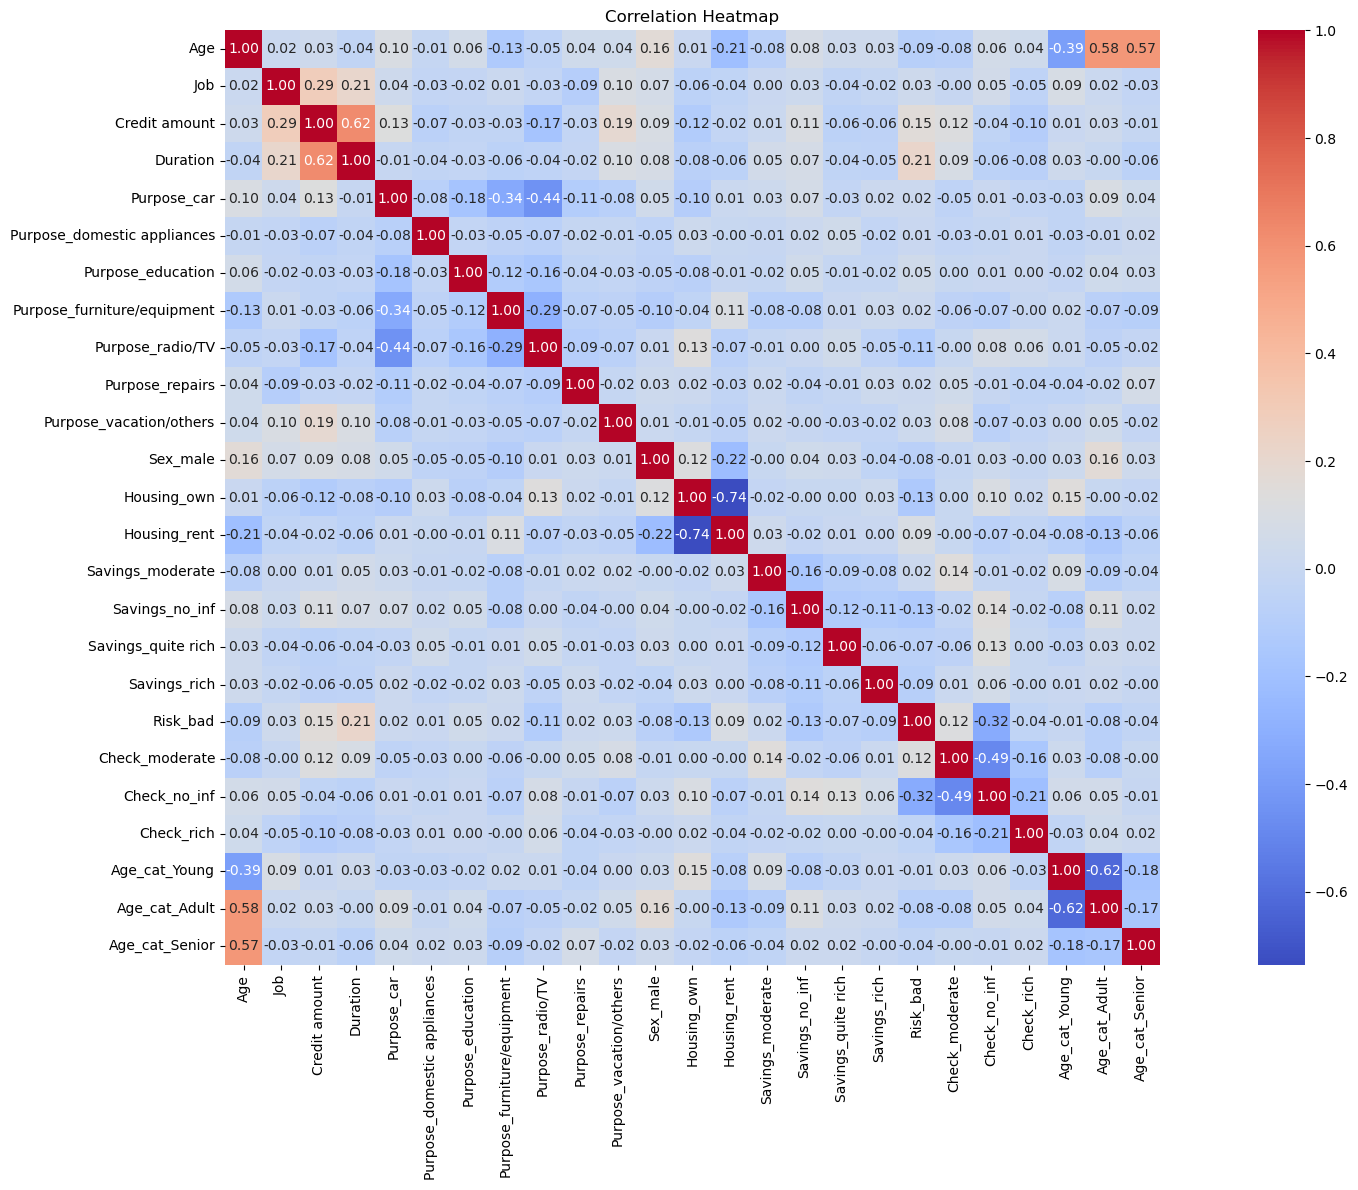

In [38]:
# correlation heatmap here
plt.figure(figsize=(20,12))
sns.heatmap(df_credit.corr(), cmap='coolwarm', annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Preparing for the regression

Change df_credit['Credit amount'] to log(df_credit['Credit amount'])
Then, split the df_credit so that y it the column "Risk_bad" and X consists of all the other columns. 
Finally, split X and y into train and test versions.

In [41]:
df_credit['Credit amount'] = np.log(df_credit['Credit amount'])


In [42]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score # to split the data
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, fbeta_score #To evaluate our model

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler

Here we preprocess the data. Why do we scale the data with MinMaxScaler? What would happen, if we didn't?

In [43]:
#Creating the X and y variables
X = df_credit.drop('Risk_bad', axis=1)
y = df_credit['Risk_bad']
# Normalize the data with the MinMaxScaler
scaler = MinMaxScaler()

# Splitting X and y into train and test version
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
%pip install xgboost

# Algorithmns models to be compared
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   - -------------------------------------- 5.8/150.0 MB 29.3 MB/s eta 0:00:05
   --- ------------------------------------ 11.3/150.0 MB 27.1 MB/s eta 0:00:06
   ---- ----------------------------------- 16.8/150.0 MB 26.4 MB/s eta 0:00:06
   ----- ---------------------------------- 22.0/150.0 MB 26.3 MB/s eta 0:00:05
   ------- -------------------------------- 27.5/150.0 MB 26.0 MB/s eta 0:00:05
   -------- ------------------------------- 32.5/150.0 MB 26.1 MB/s eta 0:00:05
   --------- ------------------------------ 36.7/150.0 MB 25.1 MB/s eta 0:00:05
   ----------- ---------------------------- 42.2/150.0 MB 25.1 MB/s eta 0:00:05
   ------------ --------------------------- 47.4/150.0 MB 25.2 MB/s eta 0:00:05
   -------------- ------------------------- 53.0/150.0 MB 25.2 MB/s eta 0:00:04
   --------------- ------------------------ 58.2/150

Estimate the credit score 'Risk_bad'. Apply the classifiers imported above to X and y. Apply cross validation with n_splits=5. You can use KFold and cross_val_score. Present your result using pyplot.boxplot

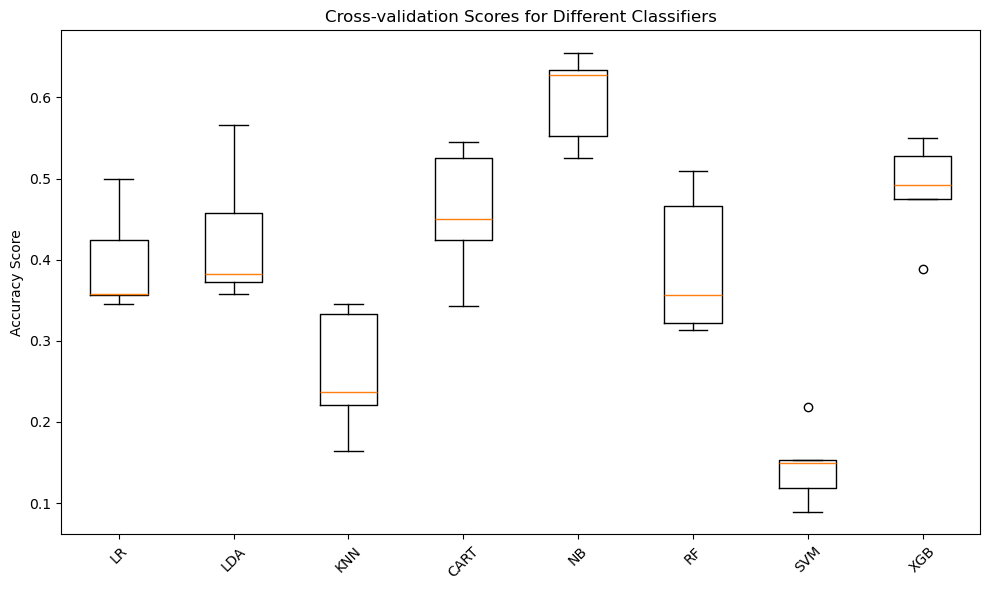

In [53]:
# to feed the random state
seed = 7

# prepare models
models = []
models.append(('LR', LogisticRegression(max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('RF', RandomForestClassifier()))
models.append(('SVM', SVC(gamma='auto')))
models.append(('XGB', XGBClassifier()))

# evaluate each model in turn
results = []
names = []
scoring = 'recall'
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models:
    scores = cross_val_score(model, X, y, cv=kf, scoring=scoring)
    results.append(scores)
    names.append(name)
        
# boxplot algorithm comparison
plt.figure(figsize=(10, 6))
plt.boxplot(results, tick_labels=names)
plt.title('Cross-validation Scores for Different Classifiers')
plt.ylabel('Accuracy Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



To close this exercise, estimate the credit score 'Risk_bad' using the random forest classifier and grid search. First, you can read https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html.

In [60]:
#Seting the Hyper Parameters
param_grid = {"max_depth": [3,5, 7, 10, None],
              "n_estimators":[3,5,10,25,50,150],
              "max_features": [4,7,15,20]}

#Creating the classifier
model = RandomForestClassifier(random_state=2)

#fill in here....
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(estimator=RandomForestClassifier(random_state=2), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'max_features': [4, 7, 15, 20],
                         'n_estimators': [3, 5, 10, 25, 50, 150]})

In [61]:
# Print the best parameters and score attained from the search
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best recall score: {grid_search.best_score_}")

# Optionally evaluate the best model on the test set
best_model = grid_search.best_estimator_
test_recall = best_model.score(X_test, y_test)
print(f"Test recall score: {test_recall}")

Best parameters: {'max_depth': None, 'max_features': 15, 'n_estimators': 25}
Best recall score: 0.7546666666666667
Test recall score: 0.736


Fill the hyperparameters obtained in the ccell below, run the classifier and compute the accuracy score, confusion matrix and fbeta score. Then, change the values of max_features and n_estimators to something else. Rerun the classifier and compare the results (accuracy scores, confusion matrix and fbeta score). Comment on the result of the comparison. 

In [62]:
rf = RandomForestClassifier(max_depth=None, max_features=15, n_estimators=25, random_state=2)

#trainning with the best params
rf.fit(X_train, y_train)

RandomForestClassifier(max_features=15, n_estimators=25, random_state=2)

Accuracy score:  0.736
FBeta score:  0.49853372434017595


Text(0.5, 1.0, 'RandomForestClassifier')

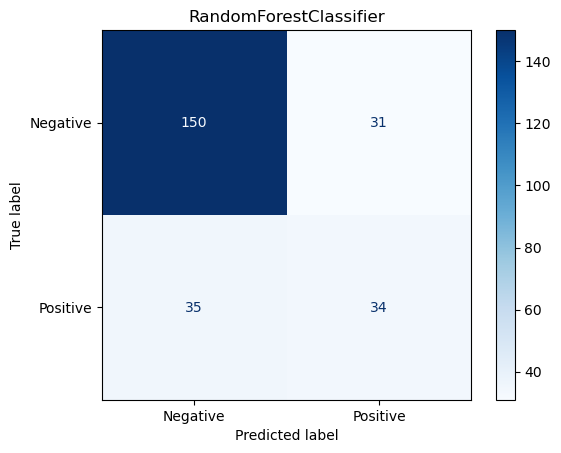

In [63]:
#Testing the model 
#Predicting using our  model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)

# Print the accuracy, confusion matrix and fbeta

# Verificate the results
print("Accuracy score: ", accuracy_score(y_test, y_pred))

print("FBeta score: ", fbeta_score(y_test, y_pred, beta=2))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues')
disp.ax_.set_title(grid_search.best_estimator_.__class__.__name__)
